In [1]:
import yfinance as yf

# Prix de dernière clôture du S&P500
ticker = yf.Ticker("^GSPC")
S0 = ticker.history(period="1d")["Close"].iloc[-1]
print(f"Prix S&P500 : {S0:.2f}")

Prix S&P500 : 6696.59


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Prix de dernière clôture du S&P500
ticker = yf.Ticker("^GSPC")
S0 = ticker.history(period="1d")["Close"].iloc[-1]
print(f"Prix S&P500 : {S0:.2f}")

# Paramètres du modèle Heston
V0 = 0.04      # Variance initiale (vol de 20% au carré)
r = 0.05       # Taux sans risque
T = 1.0        # Maturité en années
N = 252        # Nombre de pas (jours de trading)
M = 10000      # Nombre de simulations Monte Carlo

# Paramètres spécifiques à Heston
kappa = 2.0    # Vitesse de mean reversion de la variance
theta = 0.04   # Variance long terme (vol long terme = 20%)
sigma_v = 0.3  # Volatilité de la volatilité (vol of vol)
rho = -0.7     # Corrélation entre chocs sur S et chocs sur v

Prix S&P500 : 6702.72


In [4]:
# Simulation des trajectoires Heston
dt = T / N  # Pas de temps (1 jour)

# Initialisation des matrices
S = np.zeros((M, N + 1))  # M trajectoires, N+1 points de temps
V = np.zeros((M, N + 1))  # Pareil pour la variance

# Point de départ
S[:, 0] = S0
V[:, 0] = V0

# Boucle de simulation
for t in range(1, N + 1):
    
    # Deux chocs aléatoires corrélés
    Z1 = np.random.normal(0, 1, M)
    Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.normal(0, 1, M)
    
    # Variance ne peut pas être négative
    V_positive = np.maximum(V[:, t-1], 0)
    
    # Évolution de la variance (équation de Heston)
    V[:, t] = V[:, t-1] + kappa * (theta - V_positive) * dt + sigma_v * np.sqrt(V_positive * dt) * Z2
    
    # Évolution du prix
    S[:, t] = S[:, t-1] * np.exp((r - 0.5 * V_positive) * dt + np.sqrt(V_positive * dt) * Z1)

print(f"Simulation terminée : {M} trajectoires sur {N} jours")

Simulation terminée : 10000 trajectoires sur 252 jours


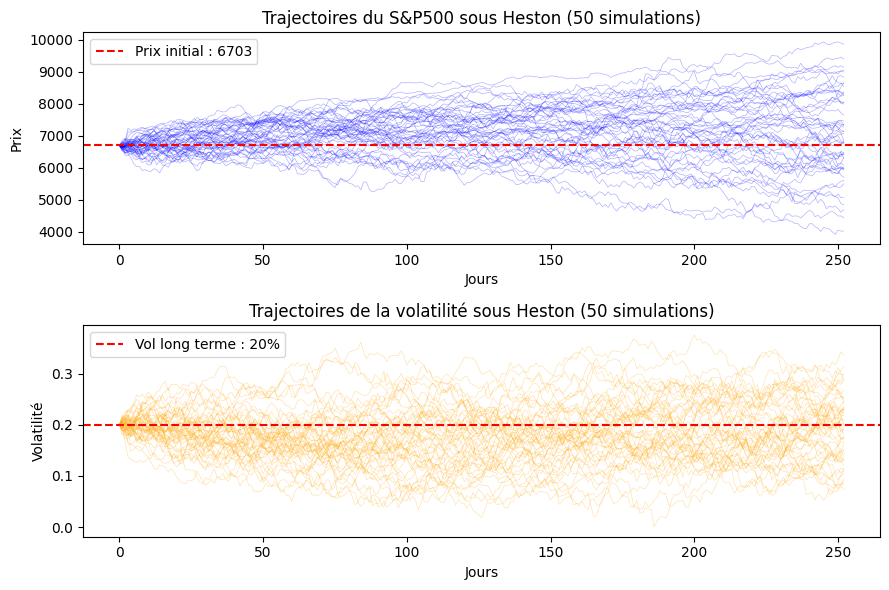

In [8]:
# Visualisation des trajectoires
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

# Graphique 1 : trajectoires du prix S
# On affiche seulement 50 trajectoires sur 10 000 pour la lisibilité du graphique
ax1.plot(S[:50, :].T, alpha=0.3, linewidth=0.5, color='blue')
ax1.axhline(y=S0, color='red', linewidth=1.5, linestyle='--', label=f'Prix initial : {S0:.0f}')
ax1.set_title('Trajectoires du S&P500 sous Heston (50 simulations)')
ax1.set_xlabel('Jours')
ax1.set_ylabel('Prix')
ax1.legend()

# Graphique 2 : trajectoires de la variance V
ax2.plot(np.sqrt(np.maximum(V[:50, :], 0)).T, alpha=0.3, linewidth=0.5, color='orange')
ax2.axhline(y=np.sqrt(theta), color='red', linewidth=1.5, linestyle='--', label=f'Vol long terme : {np.sqrt(theta)*100:.0f}%')
ax2.set_title('Trajectoires de la volatilité sous Heston (50 simulations)')
ax2.set_xlabel('Jours')
ax2.set_ylabel('Volatilité')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
# Etape 2 : Pricing call et put européens sous Heston
K = S0  # Strike = prix actuel (option at-the-money)

# Payoffs à maturité
payoff_call = np.maximum(S[:, -1] - K, 0)
payoff_put = np.maximum(K - S[:, -1], 0)

# Prix Monte Carlo
call_price = np.exp(-r * T) * np.mean(payoff_call)
put_price = np.exp(-r * T) * np.mean(payoff_put)

# Prix Black-Scholes pour comparaison
from scipy.stats import norm
sigma_bs = np.sqrt(theta)
d1 = (np.log(S0 / K) + (r + 0.5 * sigma_bs**2) * T) / (sigma_bs * np.sqrt(T))
d2 = d1 - sigma_bs * np.sqrt(T)
call_bs = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
put_bs = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

# Vérification parité call-put
parity_heston = call_price - put_price
parity_theorique = S0 - K * np.exp(-r * T)

print(f"--- Heston ---")
print(f"Prix call          : {call_price:.2f}")
print(f"Prix put           : {put_price:.2f}")
print(f"")
print(f"--- Black-Scholes ---")
print(f"Prix call BS       : {call_bs:.2f}")
print(f"Prix put BS        : {put_bs:.2f}")
print(f"")
print(f"--- Vérification parité call-put ---")
print(f"Call - Put Heston  : {parity_heston:.2f}")
print(f"S0 - Ke^(-rT)      : {parity_theorique:.2f}")

--- Heston ---
Prix call          : 695.09
Prix put           : 374.49

--- Black-Scholes ---
Prix call BS       : 700.47
Prix put BS        : 373.58

--- Vérification parité call-put ---
Call - Put Heston  : 320.60
S0 - Ke^(-rT)      : 326.90


In [13]:
# Etape 3 : Smile de volatilité Heston
from scipy.optimize import brentq

# Grille de strikes autour du prix actuel (80% à 120% de S0)
strikes = np.linspace(0.8 * S0, 1.2 * S0, 30)

# Fonction pour calculer le prix BS d'un call
def bs_call(S, K, r, T, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Fonction pour retrouver la vol implicite par inversion
def implied_vol(S, K, r, T, market_price):
    try:
        return brentq(lambda sigma: bs_call(S, K, r, T, sigma) - market_price, 1e-6, 10)
    except:
        return np.nan

# Calcul du smile Heston
iv_heston = []

for K in strikes:
    # Pricer le call Heston pour ce strike
    payoff = np.maximum(S[:, -1] - K, 0)
    price_heston = np.exp(-r * T) * np.mean(payoff)
    
    # Retrouver la vol implicite BS correspondante
    iv = implied_vol(S0, K, r, T, price_heston)
    iv_heston.append(iv)

iv_heston = np.array(iv_heston)
print("Smile calculé ")

Smile calculé 


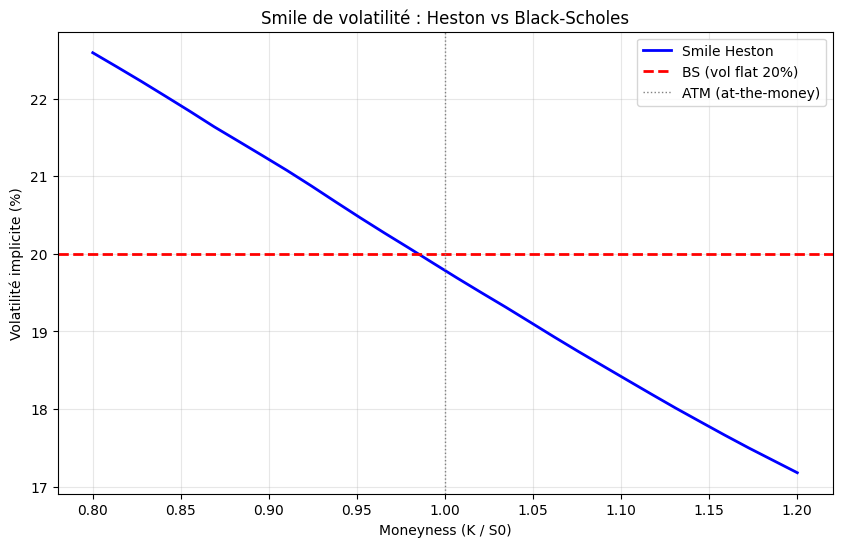

In [15]:
# Visualisation du smile de volatilité
moneyness = strikes / S0  # Axe x en % du prix actuel

# Smile BS (ligne plate) pour comparaison
iv_bs = np.ones(len(strikes)) * np.sqrt(theta)

plt.figure(figsize=(10, 6))
plt.plot(moneyness, iv_heston * 100, color='blue', linewidth=2, label='Smile Heston')
plt.axhline(y=np.sqrt(theta) * 100, color='red', linewidth=2, linestyle='--', label=f'BS (vol flat {np.sqrt(theta)*100:.0f}%)')
plt.axvline(x=1.0, color='gray', linewidth=1, linestyle=':', label='ATM (at-the-money)')
plt.title('Smile de volatilité : Heston vs Black-Scholes')
plt.xlabel('Moneyness (K / S0)')
plt.ylabel('Volatilité implicite (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Etape 4 : Smile réel du marché via yfinance
import yfinance as yf

# On utilise SPY (ETF S&P500) car yfinance ne supporte pas les options sur ^GSPC
ticker = yf.Ticker("SPY")

# Prix actuel du SPY
S0_spy = ticker.history(period="1d")["Close"].iloc[-1]
print(f"Prix SPY : {S0_spy:.2f}")

# Afficher toutes les maturités disponibles
print("Toutes les maturités disponibles :")
for i, exp in enumerate(expirations):
    print(f"  {i} : {exp}")

Prix SPY : 668.76
Toutes les maturités disponibles :
  0 : 2026-03-16
  1 : 2026-03-17
  2 : 2026-03-18
  3 : 2026-03-19
  4 : 2026-03-20
  5 : 2026-03-23
  6 : 2026-03-24
  7 : 2026-03-25
  8 : 2026-03-26
  9 : 2026-03-27
  10 : 2026-03-31
  11 : 2026-04-02
  12 : 2026-04-10
  13 : 2026-04-17
  14 : 2026-04-24
  15 : 2026-04-30
  16 : 2026-05-01
  17 : 2026-05-15
  18 : 2026-05-29
  19 : 2026-06-18
  20 : 2026-06-30
  21 : 2026-07-17
  22 : 2026-07-31
  23 : 2026-08-21
  24 : 2026-08-31
  25 : 2026-09-18
  26 : 2026-09-30
  27 : 2026-12-18
  28 : 2026-12-31
  29 : 2027-01-15
  30 : 2027-03-19
  31 : 2027-06-17
  32 : 2027-12-17
  33 : 2028-01-21
  34 : 2028-06-16
  35 : 2028-12-15


In [20]:
# On choisit la maturité la plus proche d'1 an
expiry = "2027-03-19"

# Récupération de la chain d'options
chain = ticker.option_chain(expiry)
calls = chain.calls

# On garde seulement les colonnes utiles
calls = calls[["strike", "lastPrice", "impliedVolatility"]].dropna()
calls = calls[calls["lastPrice"] > 0]  # On enlève les options sans prix

# Filtrer autour du prix actuel (80% à 120% de S0_spy)
S0_spy = ticker.history(period="1d")["Close"].iloc[-1]
calls = calls[(calls["strike"] >= 0.8 * S0_spy) & (calls["strike"] <= 1.2 * S0_spy)]

print(f"Nombre d'options récupérées : {len(calls)}")
print(calls.head(10))

Nombre d'options récupérées : 53
    strike  lastPrice  impliedVolatility
36   540.0     160.00           0.332770
37   545.0     157.49           0.329597
38   550.0     150.00           0.325111
39   555.0     142.15           0.321960
40   560.0     143.25           0.318343
41   565.0     134.60           0.315284
42   570.0     135.56           0.310783
43   575.0     126.29           0.307151
44   580.0     125.01           0.303497
45   585.0     123.56           0.299850


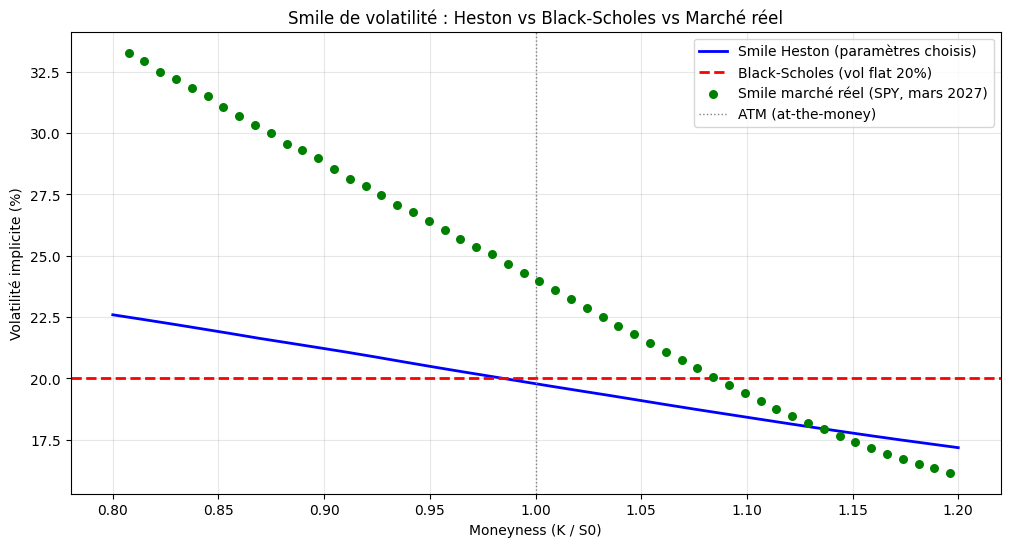

In [23]:
# Moneyness du smile marché
moneyness_market = calls["strike"] / S0_spy
iv_market = calls["impliedVolatility"] * 100

# Moneyness du smile Heston (déjà calculé)
moneyness_heston = strikes / S0

# Graphique final : 3 courbes
plt.figure(figsize=(12, 6))

plt.plot(moneyness_heston, iv_heston * 100, color='blue', linewidth=2, label='Smile Heston (paramètres choisis)')
plt.axhline(y=np.sqrt(theta) * 100, color='red', linewidth=2, linestyle='--', label='Black-Scholes (vol flat 20%)')
plt.scatter(moneyness_market, iv_market, color='green', s=30, zorder=5, label='Smile marché réel (SPY, mars 2027)')

plt.axvline(x=1.0, color='gray', linewidth=1, linestyle=':', label='ATM (at-the-money)')
plt.title('Smile de volatilité : Heston vs Black-Scholes vs Marché réel')
plt.xlabel('Moneyness (K / S0)')
plt.ylabel('Volatilité implicite (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()